# Week 2 — Concepts & Demos
### Crop Disease Detection · Preprocessing · Augmentation · Visualisation

**What this is:** small, self-contained demos that build *intuition* for the Week-2 ideas. They run in seconds on toy/synthetic data — **no dataset download needed** — and each ends in a picture you can point at.

**What this is NOT:** your project pipeline. You implement each idea on PlantVillage yourselves.

Concepts:
1. Data leakage — why duplicate leaves fake a high score
2. The fix — grouped + stratified split
3. Fit preprocessing on **train only** (and why it matters under distribution shift)
4. Augmentation = simulating field conditions
5. Never augment validation/test
6. Class imbalance & why macro-F1
7. Background-uniformity — measuring the lab-vs-field gap


## 1 · Data leakage — why duplicate leaves fake a high score
PlantVillage has multiple near-identical shots of the **same leaf**. If a random split puts copies of one leaf in *both* train and test, the model just memorises that leaf and reports a meaningless score.

**Demo:** a 1-nearest-neighbour model on a genuinely hard (noisy) task. When duplicates leak, each test image finds its twin in train and copies the answer. Fix the split and the true (much lower) score appears.

Random split (LEAKS):  0.833
Grouped split (honest):0.533


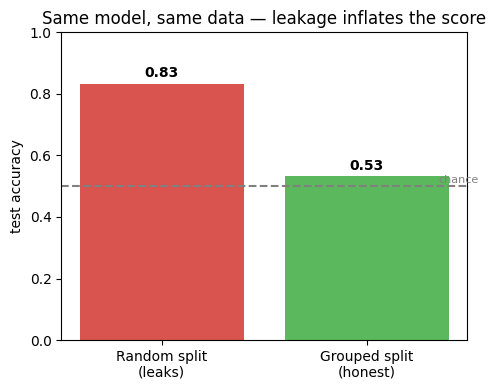

In [ ]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GroupShuffleSplit
np.random.seed(0)

N = 300
X_leaf = np.random.randn(N, 20)
base   = (X_leaf[:, 0] > 0).astype(int)
noise  = np.random.rand(N) < 0.25                 # 25% label noise -> genuinely hard
y_leaf = np.where(noise, 1 - base, base)

X = np.vstack([X_leaf, X_leaf + 0.001*np.random.randn(N, 20)])   # each leaf + its twin photo
y = np.concatenate([y_leaf, y_leaf])
leaf_id = np.concatenate([np.arange(N), np.arange(N)])

def knn_acc(tr, te):
    return KNeighborsClassifier(n_neighbors=1).fit(X[tr], y[tr]).score(X[te], y[te])

tr, te = train_test_split(np.arange(len(X)), test_size=0.3, random_state=0)
acc_leak = knn_acc(tr, te)
tr, te = next(GroupShuffleSplit(test_size=0.3, random_state=0).split(X, y, groups=leaf_id))
acc_honest = knn_acc(tr, te)

print(f"Random split (LEAKS):  {acc_leak:.3f}")
print(f"Grouped split (honest):{acc_honest:.3f}")

plt.figure(figsize=(5,4))
bars = plt.bar(['Random split\n(leaks)', 'Grouped split\n(honest)'],
               [acc_leak, acc_honest], color=['#d9534f', '#5cb85c'])
plt.axhline(0.5, ls='--', color='grey'); plt.text(1.35, 0.51, 'chance', color='grey', fontsize=8)
for b, v in zip(bars, [acc_leak, acc_honest]):
    plt.text(b.get_x()+b.get_width()/2, v+0.02, f'{v:.2f}', ha='center', fontweight='bold')
plt.ylim(0, 1); plt.ylabel('test accuracy')
plt.title('Same model, same data — leakage inflates the score')
plt.tight_layout(); plt.show()

#near identical split group/stratified -> put the samples in same training or test group.

## 2 · The fix — grouped **and** stratified split
- **Grouped:** every photo of one leaf stays on the same side (no leakage).
- **Stratified:** every class stays proportional in each split.

Two pictures: (1) each leaf is entirely one colour → no leaf crosses the wall; (2) class proportions survive the split.

Groups crossing train/test: 0 (must be 0)


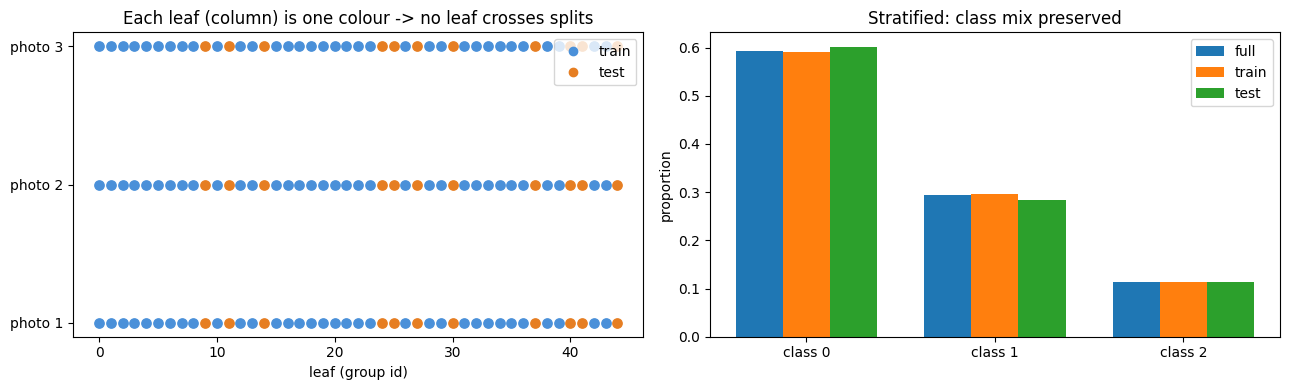

In [9]:
from sklearn.model_selection import StratifiedGroupKFold
import numpy as np, matplotlib.pyplot as plt
np.random.seed(1)

n = 600
y      = np.random.choice([0,1,2], size=n, p=[0.6,0.3,0.1])   # imbalanced
groups = np.repeat(np.arange(n//3), 3)                        # ~3 photos per leaf
tr, te = next(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=1)
              .split(np.zeros(n), y, groups=groups))

print("Groups crossing train/test:", len(set(groups[tr]) & set(groups[te])), "(must be 0)")

split_of = np.empty(n, dtype=object); split_of[tr] = 'train'; split_of[te] = 'test'
cmap = {'train':'#4a90d9', 'test':'#e67e22'}

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for g in range(45):
    for k, m in enumerate(np.where(groups == g)[0]):
        ax[0].scatter(g, k, color=cmap[split_of[m]], s=45)
ax[0].set_yticks([0,1,2]); ax[0].set_yticklabels(['photo 1','photo 2','photo 3'])
ax[0].set_xlabel('leaf (group id)')
ax[0].set_title('Each leaf (column) is one colour -> no leaf crosses splits')
ax[0].legend(handles=[plt.Line2D([0],[0],marker='o',ls='',color=c,label=k) for k,c in cmap.items()])

labels_c = sorted(np.unique(y)); x = np.arange(len(labels_c)); w = 0.25
ax[1].bar(x-w, [np.mean(y==c)     for c in labels_c], w, label='full')
ax[1].bar(x,   [np.mean(y[tr]==c) for c in labels_c], w, label='train')
ax[1].bar(x+w, [np.mean(y[te]==c) for c in labels_c], w, label='test')
ax[1].set_xticks(x); ax[1].set_xticklabels([f'class {c}' for c in labels_c])
ax[1].set_ylabel('proportion'); ax[1].set_title('Stratified: class mix preserved'); ax[1].legend()
plt.tight_layout(); plt.show()


## 3 · Fit preprocessing on **train only** — and why it matters under shift
Field images differ from lab images (distribution **shift**). If you fit your normalisation on the whole dataset, you quietly launder that shift away and hide a problem you needed to see. Fit on **train only**.

**Demo:** test data carries a real shift on feature 0. A train-only scaler reveals it; an all-data scaler buries it.

Mean of scaled TEST feature 0 - fit on ALL (leaks): +1.04  (shift hidden)
Mean of scaled TEST feature 0 - fit on TRAIN      : +1.97  (shift visible)


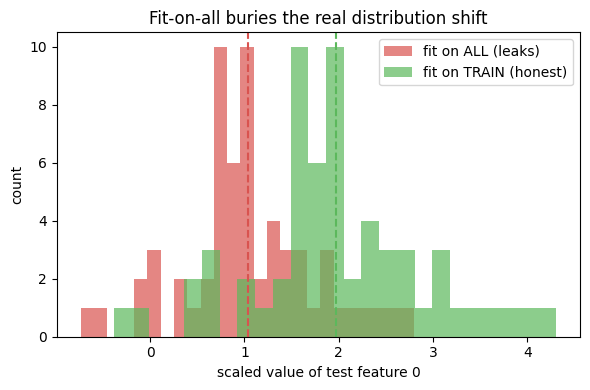

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np, matplotlib.pyplot as plt
np.random.seed(2)

X = np.random.randn(200, 5)
Xtr, Xte = X[:140].copy(), X[140:].copy()
Xte[:, 0] += 2.0                                   # test/'field' shift on feature 0

s_all = StandardScaler().fit(np.vstack([Xtr, Xte]))   # WRONG: peeks at test
s_tr  = StandardScaler().fit(Xtr)                     # RIGHT: train only
leak_f0   = s_all.transform(Xte)[:, 0]
honest_f0 = s_tr.transform(Xte)[:, 0]

print(f"Mean of scaled TEST feature 0 - fit on ALL (leaks): {leak_f0.mean():+.2f}  (shift hidden)")
print(f"Mean of scaled TEST feature 0 - fit on TRAIN      : {honest_f0.mean():+.2f}  (shift visible)")

plt.figure(figsize=(6,4))
plt.hist(leak_f0,   bins=25, alpha=0.7, color='#d9534f', label='fit on ALL (leaks)')
plt.hist(honest_f0, bins=25, alpha=0.7, color='#5cb85c', label='fit on TRAIN (honest)')
plt.axvline(leak_f0.mean(), color='#d9534f', ls='--'); plt.axvline(honest_f0.mean(), color='#5cb85c', ls='--')
plt.xlabel('scaled value of test feature 0'); plt.ylabel('count')
plt.title('Fit-on-all buries the real distribution shift'); plt.legend()
plt.tight_layout(); plt.show()
 
#512x512, 254x254, 256x256

## 4 · Augmentation = simulating field conditions
Your augmentation policy **is** your feature engineering and your domain-shift strategy. Each transform should map to a way a real field photo differs from a clean lab photo. (Here we use PIL just to *see* it; in your project you'll use `torchvision.transforms` or Keras layers.)

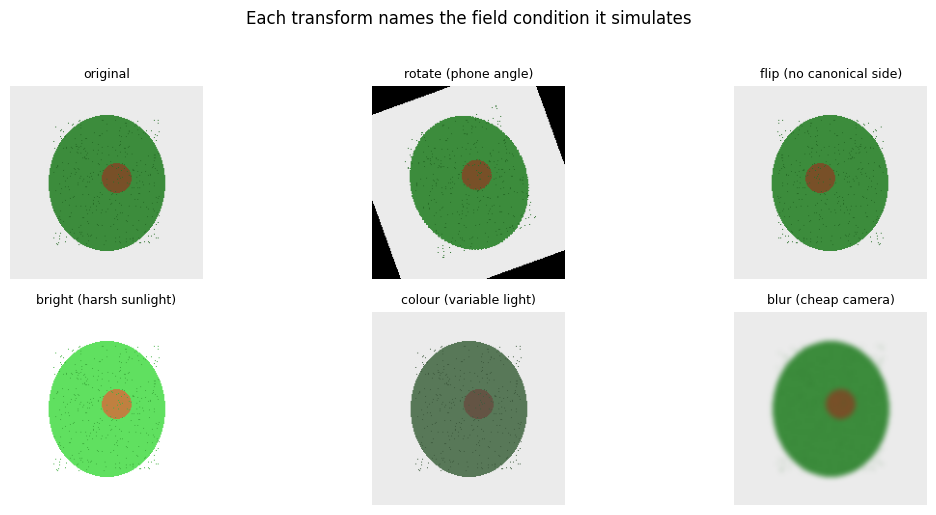

In [11]:
from PIL import Image, ImageEnhance, ImageFilter, ImageDraw
import numpy as np, matplotlib.pyplot as plt

img = Image.new('RGB', (200,200), (235,235,235))
d = ImageDraw.Draw(img)
d.ellipse([40,30,160,170], fill=(60,140,60))          # leaf
d.ellipse([95,80,125,110], fill=(120,80,40))          # lesion
for _ in range(400):
    d.point((np.random.randint(45,155), np.random.randint(35,165)), fill=(40,110,40))

augs = {
    'original'                  : img,
    'rotate (phone angle)'      : img.rotate(20),
    'flip (no canonical side)'  : img.transpose(Image.FLIP_LEFT_RIGHT),
    'bright (harsh sunlight)'   : ImageEnhance.Brightness(img).enhance(1.6),
    'colour (variable light)'   : ImageEnhance.Color(img).enhance(0.4),
    'blur (cheap camera)'       : img.filter(ImageFilter.GaussianBlur(2.5)),
}
plt.figure(figsize=(12,5))
for i,(name,a) in enumerate(augs.items()):
    plt.subplot(2,3,i+1); plt.imshow(a); plt.axis('off'); plt.title(name, fontsize=9)
plt.suptitle("Each transform names the field condition it simulates", y=1.02)
plt.tight_layout(); plt.show()


## 5 · Augment **training only** — never validation or test
Training augmentation teaches robustness. Val/test must reflect reality **unchanged** (resize + normalise only, no randomness), or your metric measures a distorted world.

**Demo:** the train transform gives a different brightness every call (a spread); the eval transform gives one fixed value.

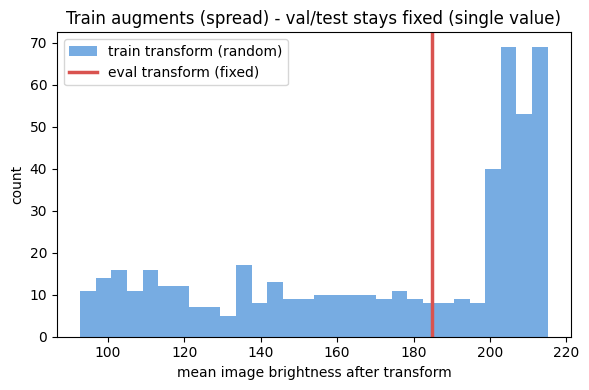

In [12]:
from PIL import ImageEnhance
import numpy as np, matplotlib.pyplot as plt

def train_transform(im):   # random -> different every call
    return np.asarray(ImageEnhance.Brightness(im).enhance(np.random.uniform(0.5, 1.6))).mean()
def eval_transform(im):    # deterministic -> identical every call
    return np.asarray(im.resize((224,224))).mean()

tr_vals = [train_transform(img) for _ in range(500)]
ev_val  = eval_transform(img)

plt.figure(figsize=(6,4))
plt.hist(tr_vals, bins=30, alpha=0.75, color='#4a90d9', label='train transform (random)')
plt.axvline(ev_val, color='#d9534f', lw=2.5, label='eval transform (fixed)')
plt.xlabel('mean image brightness after transform'); plt.ylabel('count')
plt.title('Train augments (spread) - val/test stays fixed (single value)'); plt.legend()
plt.tight_layout(); plt.show()


## 6 · Class imbalance & why you're graded on macro-F1
**Accuracy** rewards favouring big classes; **macro-F1** averages per-class F1 equally, so ignoring rare classes is punished.

**Demo:** a lazy model that always predicts the majority class — high accuracy, near-zero macro-F1, and the per-class bars show exactly why.

Accuracy : 0.710   |   Macro-F1 : 0.083


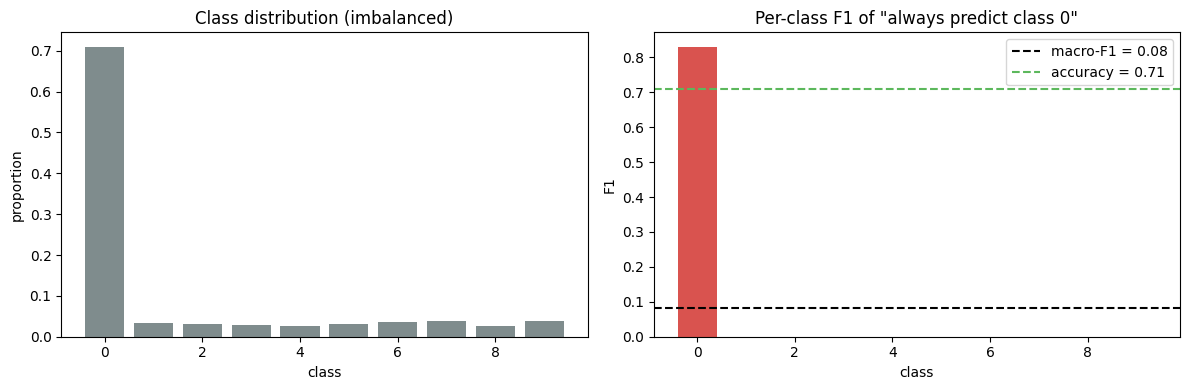

In [13]:
from sklearn.metrics import accuracy_score, f1_score
import numpy as np, matplotlib.pyplot as plt
np.random.seed(3)

y_true = np.random.choice(range(10), size=2000, p=[0.7]+[0.3/9]*9)   # class 0 = 70%
y_lazy = np.zeros_like(y_true)                                        # always predict class 0

acc  = accuracy_score(y_true, y_lazy)
mf1  = f1_score(y_true, y_lazy, average='macro')
perc = f1_score(y_true, y_lazy, average=None, labels=range(10))
print(f"Accuracy : {acc:.3f}   |   Macro-F1 : {mf1:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].bar(range(10), [np.mean(y_true==c) for c in range(10)], color='#7f8c8d')
ax[0].set_title('Class distribution (imbalanced)'); ax[0].set_xlabel('class'); ax[0].set_ylabel('proportion')
ax[1].bar(range(10), perc, color='#d9534f')
ax[1].axhline(mf1, ls='--', color='black',   label=f'macro-F1 = {mf1:.2f}')
ax[1].axhline(acc, ls='--', color='#5cb85c', label=f'accuracy = {acc:.2f}')
ax[1].set_title('Per-class F1 of "always predict class 0"'); ax[1].set_xlabel('class'); ax[1].set_ylabel('F1'); ax[1].legend()
plt.tight_layout(); plt.show()


## 7 · Measuring the lab-vs-field gap (your key EDA figure)
Lab backgrounds are near-constant; field backgrounds aren't. Quantify it as pixel variance in the image **border**. Run this on PlantVillage and on your own field photos — the distributions won't overlap. **This is the figure that proves your thesis.**

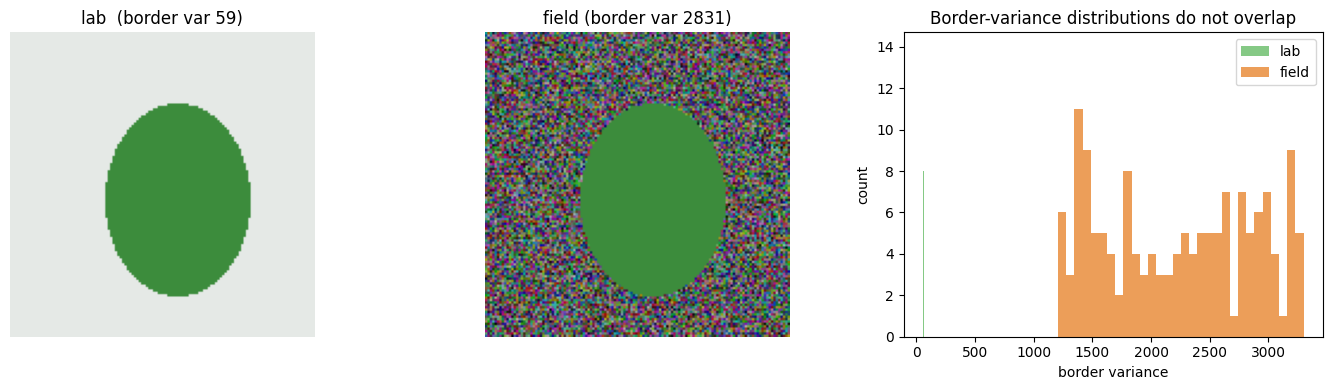

This is the shape of the plot you will produce on PlantVillage vs your own field photos.


In [14]:
from PIL import Image, ImageDraw
import numpy as np, matplotlib.pyplot as plt

def border_variance(im, frac=0.15):
    a = np.asarray(im.convert('RGB').resize((128,128)), dtype=np.float32)
    b = int(128*frac)
    border = np.concatenate([a[:b].reshape(-1,3), a[-b:].reshape(-1,3),
                             a[:,:b].reshape(-1,3), a[:,-b:].reshape(-1,3)])
    return float(border.var(axis=0).mean())

def make_lab():
    im = Image.new('RGB', (128,128), tuple(int(v) for v in np.random.randint(220,245,3)))
    ImageDraw.Draw(im).ellipse([40,30,100,110], fill=(60,140,60)); return im
def make_field():
    im = Image.fromarray((np.random.rand(128,128,3)*np.random.randint(120,200)).astype('uint8'))
    ImageDraw.Draw(im).ellipse([40,30,100,110], fill=(60,140,60)); return im

lab_img, field_img = make_lab(), make_field()
lab_bv   = [border_variance(make_lab())   for _ in range(150)]
field_bv = [border_variance(make_field()) for _ in range(150)]

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].imshow(lab_img);   ax[0].axis('off'); ax[0].set_title(f'lab  (border var {border_variance(lab_img):.0f})')
ax[1].imshow(field_img); ax[1].axis('off'); ax[1].set_title(f'field (border var {border_variance(field_img):.0f})')
ax[2].hist(lab_bv,   bins=30, alpha=0.75, color='#5cb85c', label='lab')
ax[2].hist(field_bv, bins=30, alpha=0.75, color='#e67e22', label='field')
ax[2].set_title('Border-variance distributions do not overlap')
ax[2].set_xlabel('border variance'); ax[2].set_ylabel('count'); ax[2].legend()
plt.tight_layout(); plt.show()
print("This is the shape of the plot you will produce on PlantVillage vs your own field photos.")


## Takeaways to carry into your project
1. Split **before** you touch the data; group by leaf; stratify by class.
2. Fit every preprocessing statistic on **train only** — especially under lab->field shift.
3. Make each augmentation a **named field condition**; augment **train only**.
4. **Visualise** augmented batches (sanity) and the background-variance gap (evidence).
5. Report **macro-F1**, and handle class imbalance deliberately.

None of this is model-building — that's Weeks 3+. This week is getting the data honest and understood.
